# 1) Libraries

In [9]:
import os
import random
import cv2
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

HAS_XGB = True
try:
    from xgboost import XGBClassifier
except ImportError:
    HAS_XGB = False

HAS_LGBM = True
try:
    from lightgbm import LGBMClassifier
except ImportError:
    HAS_LGBM = False

import warnings
warnings.filterwarnings('ignore')    

# 2) Dataset Overview

In [ ]:
DATASET_DIR = r"C:\Users\shbka\OneDrive\Desktop\Lumbar Disc Herniation Detection\Data-0"
normal_folder = r"C:\Users\shbka\OneDrive\Desktop\Lumbar Disc Herniation Detection\Data-0\Normal"
abnormal_folder = r"C:\Users\shbka\OneDrive\Desktop\Lumbar Disc Herniation Detection\Data-0\Abnormal"

classes = ['Normal', 'Abnormal']
folders = [normal_folder, abnormal_folder]

data = []
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

for label in classes:
    class_dir = os.path.join(DATASET_DIR, label)
    
    if not os.path.exists(class_dir):
        print(f"Warning: Folder not found -> {class_dir}")
        continue
    
    for file_name in os.listdir(class_dir):
        if file_name.lower().endswith(valid_extensions):
            img_path = os.path.join(class_dir, file_name)
            data.append({
                "image_path": img_path,
                "label": label
            })

df = pd.DataFrame(data)

print("Dataset Overview")
print("=" * 40)
print(f"Total images: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")
print("\nClass distribution:")
print(df["label"].value_counts())

Dataset Overview
Total images: 1426
Number of classes: 2

Class distribution:
label
Abnormal    755
Normal      671
Name: count, dtype: int64


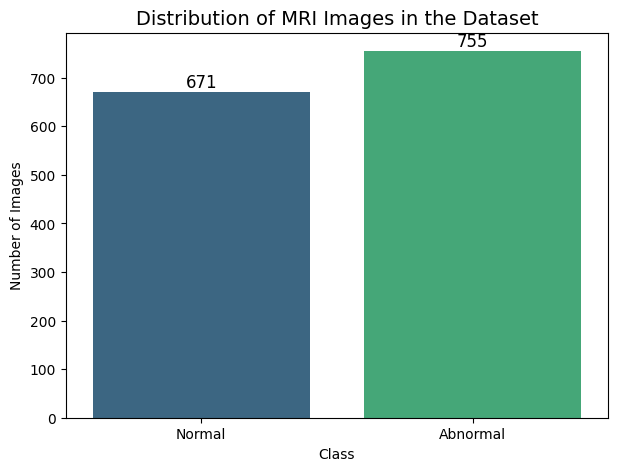

In [ ]:
counts = [671, 755]

plt.figure(figsize=(7, 5))
sns.barplot(
    x=classes,
    y=counts,
    palette="viridis"
)
plt.title("Distribution of MRI Images in the Dataset", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center', fontsize=12)

plt.grid(axis='y', linestyle='', alpha=0.6)
plt.show()

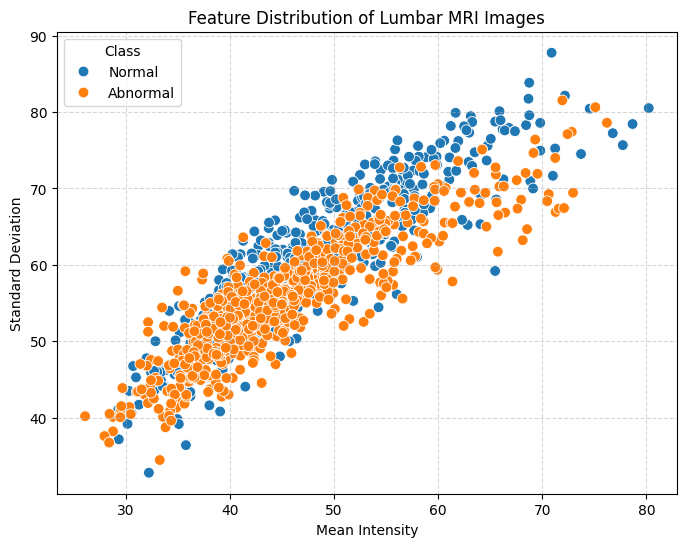

In [96]:
data = []

def extract_features(folder, label_name):
    for f in os.listdir(folder):
        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        mean_intensity = np.mean(img)
        std_intensity = np.std(img)

        data.append([mean_intensity, std_intensity, label_name])

extract_features(normal_folder, "Normal")
extract_features(abnormal_folder, "Abnormal")

means = [x[0] for x in data]
stds = [x[1] for x in data]
labels = [x[2] for x in data]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=means, y=stds, hue=labels, s=60)
plt.title("Feature Distribution of Lumbar MRI Images")
plt.xlabel("Mean Intensity")
plt.ylabel("Standard Deviation")
plt.legend(title="Class")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

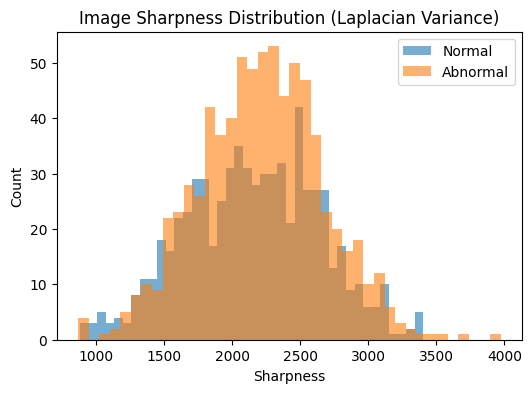

Normal: mean=2152.93, std=491.30
Abnormal: mean=2211.54, std=456.44


In [111]:
def laplacian_variance(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(img, cv2.CV_64F).var()

sharpness = {}

for cls in classes:
    values = []
    cls_path = os.path.join(DATA_PATH, cls)

    for img in os.listdir(cls_path):
        v = laplacian_variance(os.path.join(cls_path, img))
        values.append(v)

    sharpness[cls] = np.array(values)

plt.figure(figsize=(6, 4))

for cls in classes:
    plt.hist(sharpness[cls], bins=40, alpha=0.6, label=cls)

plt.title("Image Sharpness Distribution (Laplacian Variance)")
plt.xlabel("Sharpness")
plt.ylabel("Count")
plt.legend()
plt.show()

for cls in classes:
    print(f"{cls}: mean={sharpness[cls].mean():.2f}, std={sharpness[cls].std():.2f}")

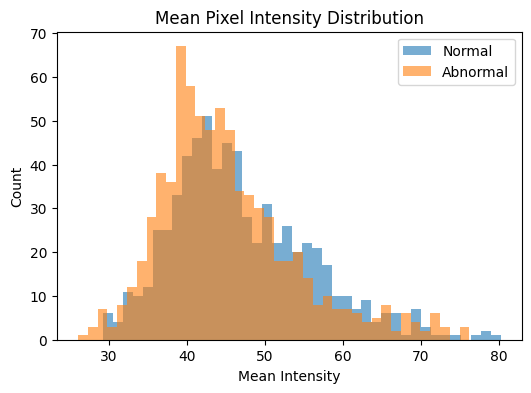

Normal: mean=47.02, std=8.95
Abnormal: mean=45.18, std=8.79


In [112]:
intensity_stats = {}

for cls in classes:
    values = []
    cls_path = os.path.join(DATA_PATH, cls)

    for img in os.listdir(cls_path):
        im = Image.open(os.path.join(cls_path, img)).convert("L")
        values.append(np.array(im).mean())

    intensity_stats[cls] = np.array(values)

plt.figure(figsize=(6, 4))

for cls in classes:
    plt.hist(intensity_stats[cls], bins=40, alpha=0.6, label=cls)

plt.title("Mean Pixel Intensity Distribution")
plt.xlabel("Mean Intensity")
plt.ylabel("Count")
plt.legend()
plt.show()

for cls in classes:
    print(f"{cls}: mean={intensity_stats[cls].mean():.2f}, std={intensity_stats[cls].std():.2f}")

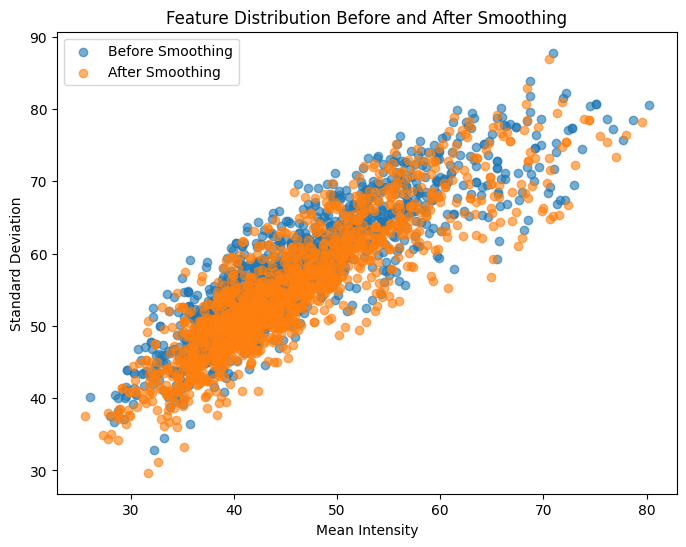

In [119]:
mean_before = []
std_before = []
mean_after = []
std_after = []


for folder in folders:
    for f in os.listdir(folder):

        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        mean_before.append(np.mean(img))
        std_before.append(np.std(img))

        smooth = cv2.bilateralFilter(img, 5, 50, 50)

        mean_after.append(np.mean(smooth))
        std_after.append(np.std(smooth))

plt.figure(figsize=(8, 6))
plt.scatter(mean_before, std_before, alpha=0.6, label="Before Smoothing")
plt.scatter(mean_after, std_after, alpha=0.6, label="After Smoothing")
plt.title("Feature Distribution Before and After Smoothing")
plt.xlabel("Mean Intensity")
plt.ylabel("Standard Deviation")
plt.legend()
plt.show()

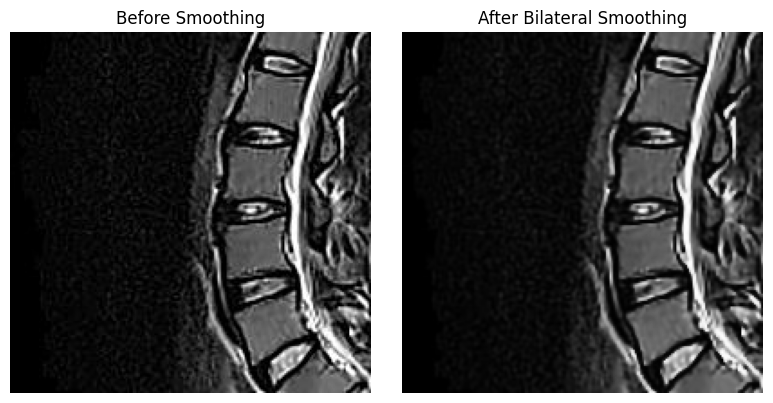

In [ ]:
all_images = []

for folder in folders:
    for f in os.listdir(folder):
        path = os.path.join(folder, f)
        if os.path.isfile(path):
            all_images.append(path)

img_path = random.choice(all_images)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (200, 200))

smooth = cv2.bilateralFilter(img, 1, 50, 50)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Before Smoothing")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(smooth, cmap='gray')
plt.title("After Bilateral Smoothing")
plt.axis("off")
plt.tight_layout()
plt.show()

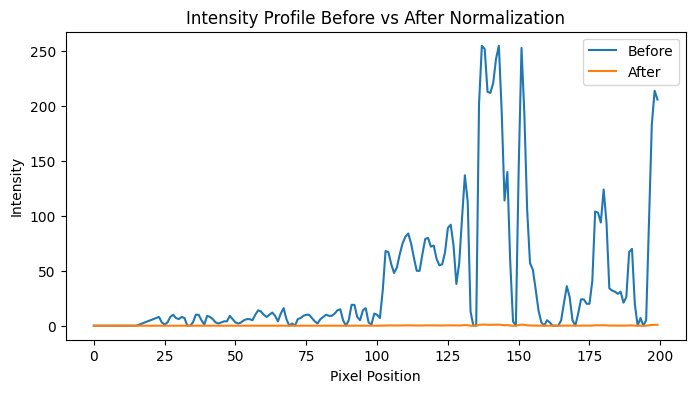

In [ ]:
img = img  
norm = img / 255.0
row = 100

plt.figure(figsize=(8, 4))
plt.plot(img[row], label="Before")
plt.plot(norm[row], label="After")
plt.title("Intensity Profile Before vs After Normalization")
plt.xlabel("Pixel Position")
plt.ylabel("Intensity")
plt.legend()
plt.show()

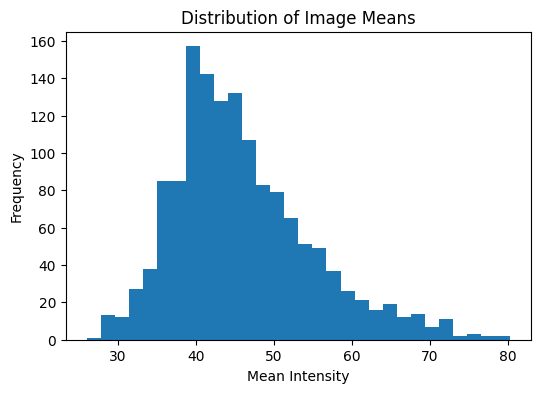

In [121]:
images = []

for folder in folders:
    for f in os.listdir(folder):

        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        images.append(img)


means = [np.mean(img) for img in images]

plt.figure(figsize=(6, 4))
plt.hist(means, bins=30)
plt.title("Distribution of Image Means")
plt.xlabel("Mean Intensity")
plt.ylabel("Frequency")
plt.show()

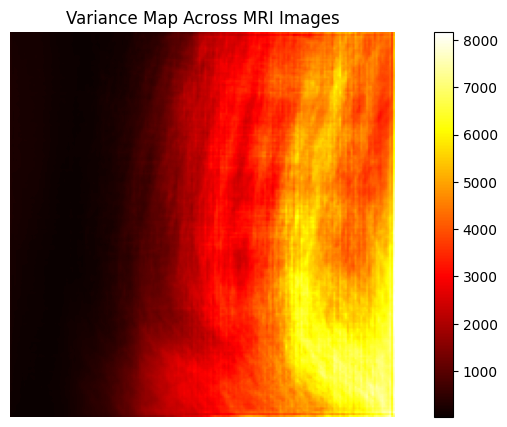

In [122]:
images = []

for folder in folders:
    for f in os.listdir(folder):

        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        images.append(img)

images = np.array(images)
var_img = np.var(images, axis=0)

plt.figure(figsize=(10, 5))
plt.imshow(var_img, cmap='hot')
plt.title("Variance Map Across MRI Images")
plt.axis('off')
plt.colorbar()
plt.show()

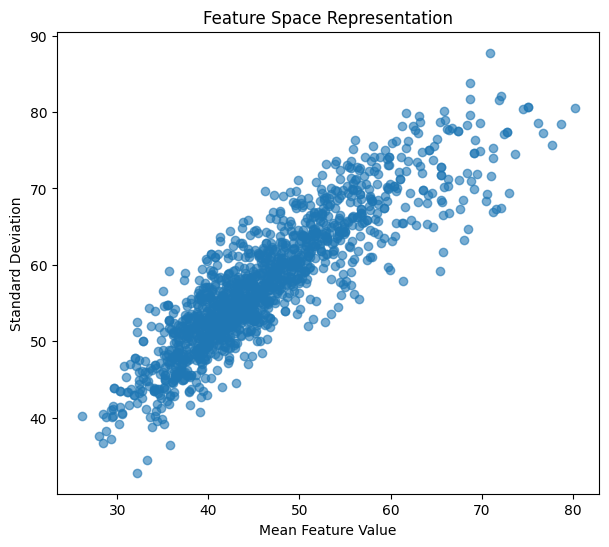

In [123]:
x = [] 

for folder in folders:
    for f in os.listdir(folder):

        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        # Resize
        img = cv2.resize(img, (200, 200))

        # Flatten
        feature_vector = img.flatten()

        x.append(feature_vector)

x = np.array(x)

means = np.mean(x, axis=1)
stds = np.std(x, axis=1)

plt.figure(figsize=(7, 6))
plt.scatter(means, stds, alpha=0.6)
plt.xlabel("Mean Feature Value")
plt.ylabel("Standard Deviation")
plt.title("Feature Space Representation")
plt.show()

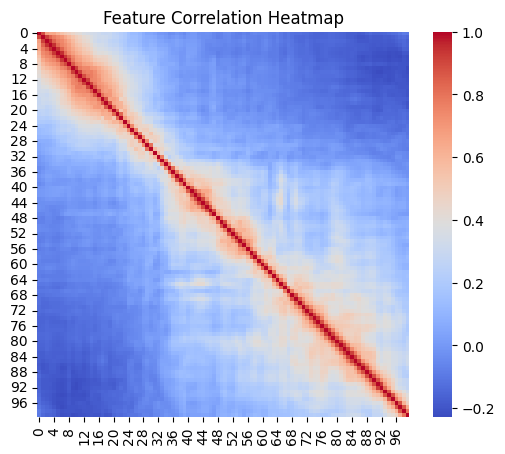

In [109]:
subset = x[:, :100]  

corr = np.corrcoef(subset, rowvar=False)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Total images: 1426
Total labels: 1426


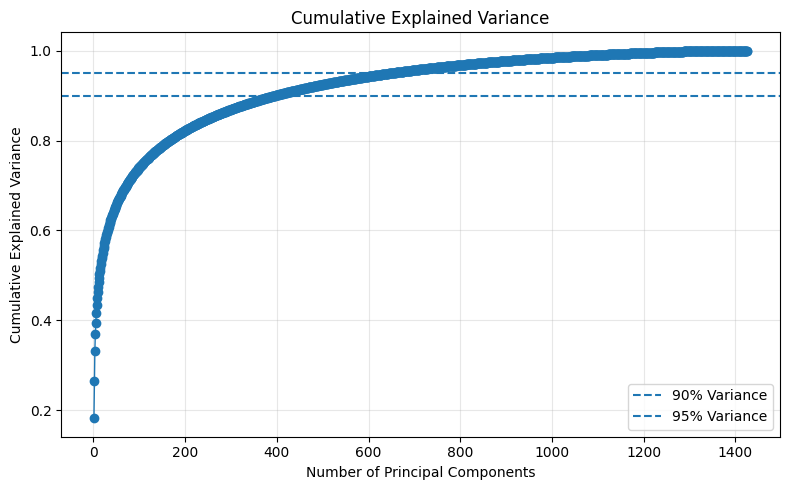

In [124]:
images = []
labels = []
IMG_SIZE = 200

for file_name in os.listdir(normal_folder):
    file_path = os.path.join(normal_folder, file_name)
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(0)

for file_name in os.listdir(abnormal_folder):
    file_path = os.path.join(abnormal_folder, file_name)
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(1)

print("Total images:", len(images))
print("Total labels:", len(labels))

x1 = np.array([img.flatten() for img in images], dtype=np.float32)
y = np.array(labels)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o', linewidth=1)
plt.axhline(y=0.90, linestyle='--', label='90% Variance')
plt.axhline(y=0.95, linestyle='--', label='95% Variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cumulative_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1

# 3) Training and Evaluation for all algorithms

In [ ]:
IMG_SIZE = (224, 224)
TEST_SIZE = 0.15
RANDOM_STATE = 42

component_list = [
    2, 3, 4, 5,
    12, 20, 28,
    30, 33, 38, 40, 44, 52, 58,
    60, 78, 80, 82, 84, 86, 90, 96, 100
]

In [ ]:
def smooth_image(img):
    return cv2.bilateralFilter(img, d=5, sigmaColor=50, sigmaSpace=50)


def load_pixels_smoothed_all(base_dir, classes, img_size):
    X, y = [], []

    for label, cls in enumerate(classes):
        cls_dir = os.path.join(base_dir, cls)

        if not os.path.isdir(cls_dir):
            continue

        for fn in os.listdir(cls_dir):
            path = os.path.join(cls_dir, fn)

            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, img_size)
            img = smooth_image(img)

            arr = img.astype(np.float32) / 255.0

            X.append(arr.flatten())
            y.append(label)

    return np.array(X), np.array(y)

In [ ]:
print("Loading data...")

X, y = load_pixels_smoothed_all(DATA_DIR, classes, IMG_SIZE)

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

In [ ]:
models = {

    "KNN": KNeighborsClassifier(
        n_neighbors=3,
        weights="distance"
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM_RBF": SVC(
        C=2,
        gamma="scale",
        kernel="rbf",
        class_weight="balanced"
    ),

    "LogisticRegression": LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "DecisionTree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )
}

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
else:
    print("XGBoost not installed, so it will be skipped.")

if HAS_LGBM:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=600,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
else:
    print("LightGBM not installed, so it will be skipped.")

print("\nNumber of active models:", len(models))
print("Models:", list(models.keys()))

In [ ]:
final_results = []

print("\n=========== PCA SWEEP FOR 10 MODELS ===========\n")

for model_name, model in models.items():

    print(f"\n==================== {model_name} ====================")

    best_result = {
        "model_name": model_name,
        "pca": None,
        "acc": 0,
        "precision": 0,
        "recall": 0,
        "f1": 0,
        "cm": None,
        "report": None
    }

    for n_comp in component_list:

        if n_comp >= X_train.shape[1]:
            continue

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_comp, random_state=42)),
            ("clf", model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        print(
            f"PCA={n_comp:>3} | "
            f"Acc={acc:.4f} | "
            f"Precision={precision:.4f} | "
            f"Recall={recall:.4f} | "
            f"F1={f1:.4f}"
        )

        if f1 > best_result["f1"]:
            best_result["pca"] = n_comp
            best_result["acc"] = acc
            best_result["precision"] = precision
            best_result["recall"] = recall
            best_result["f1"] = f1
            best_result["cm"] = confusion_matrix(y_test, y_pred)
            best_result["report"] = classification_report(
                y_test,
                y_pred,
                target_names=classes,
                zero_division=0
            )

    print(f"\nBEST FOR {model_name}")
    print(f"PCA       : {best_result['pca']}")
    print(f"Accuracy  : {best_result['acc']:.4f}")
    print(f"Precision : {best_result['precision']:.4f}")
    print(f"Recall    : {best_result['recall']:.4f}")
    print(f"F1-score  : {best_result['f1']:.4f}")
    print("Confusion Matrix:")
    print(best_result["cm"])
    print("Classification Report:")
    print(best_result["report"])

    final_results.append(best_result)

In [ ]:
final_results = sorted(final_results, key=lambda x: x["f1"], reverse=True)

print("\n=========== FINAL COMPARISON BETWEEN 10 ALGORITHMS ===========\n")

for i, result in enumerate(final_results, start=1):
    print(
        f"{i:02d}) {result['model_name']:<20} | "
        f"PCA={result['pca']:<3} | "
        f"Acc={result['acc']:.4f} | "
        f"Precision={result['precision']:.4f} | "
        f"Recall={result['recall']:.4f} | "
        f"F1={result['f1']:.4f}"
    )

best_overall = final_results[0]

print("\n=========== BEST ALGORITHM OVERALL ===========\n")

print(f"Best Model : {best_overall['model_name']}")
print(f"Best PCA   : {best_overall['pca']}")
print(f"Accuracy   : {best_overall['acc']:.4f}")
print(f"Precision  : {best_overall['precision']:.4f}")
print(f"Recall     : {best_overall['recall']:.4f}")
print(f"F1-score   : {best_overall['f1']:.4f}")

print("Confusion Matrix:")
print(best_overall["cm"])

print("Classification Report:")
print(best_overall["report"])

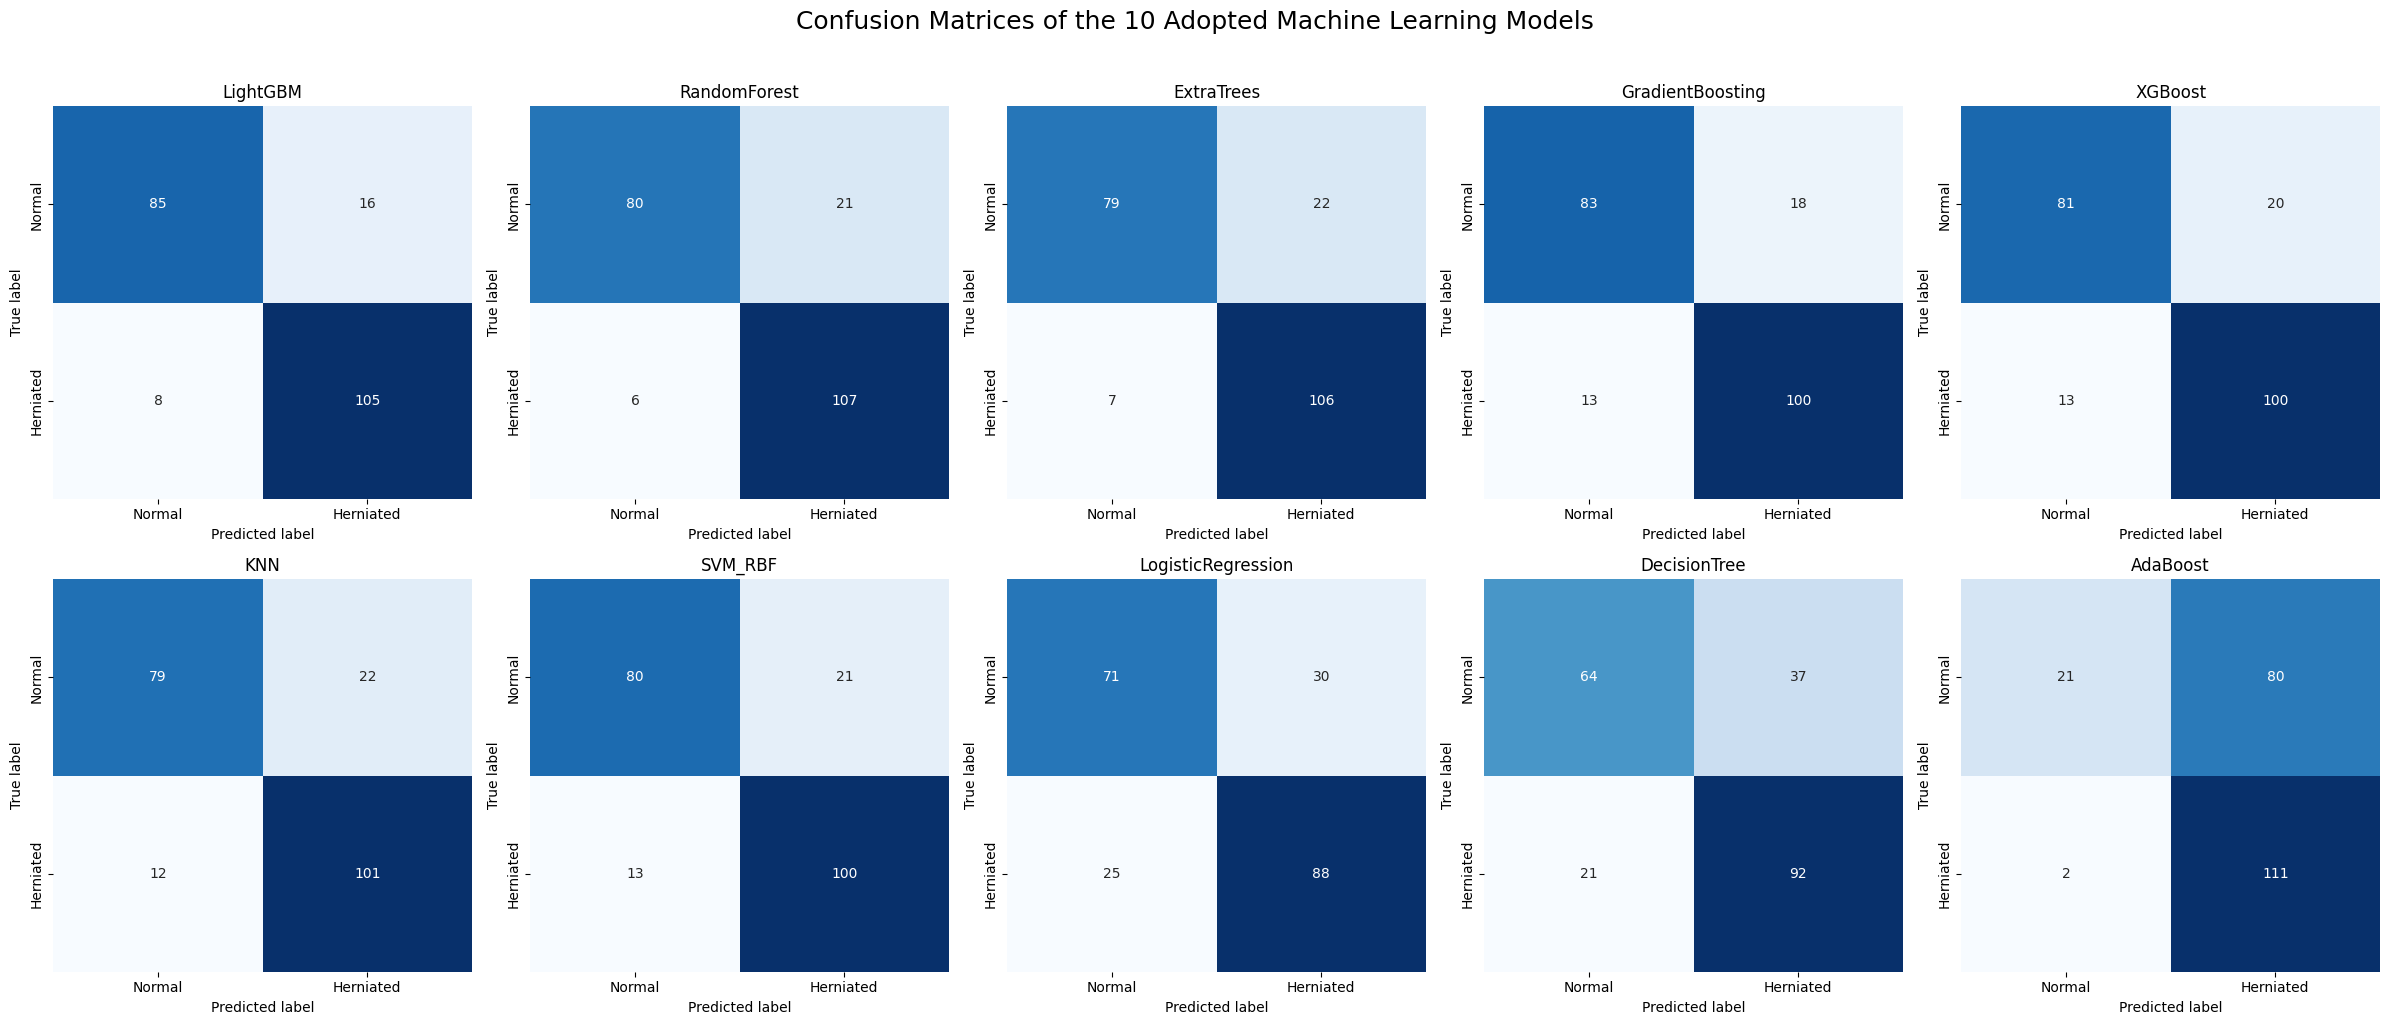

In [ ]:
results_to_plot = final_results

display_labels = ["Normal", "Herniated"]

n_models = len(results_to_plot)
n_cols = 5
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 10))
axes = axes.flatten()

for i, result in enumerate(results_to_plot):
    model_name = result["model_name"]
    cm = result["cm"]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=display_labels,
        yticklabels=display_labels,
        ax=axes[i]
    )

    axes[i].set_title(model_name, fontsize=12)
    axes[i].set_xlabel("Predicted label")
    axes[i].set_ylabel("True label")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Confusion Matrices of the 10 Adopted Machine Learning Models",
    fontsize=18,
    y=1.02
)
plt.tight_layout()
plt.savefig("confusion_matrices_best_models.png", dpi=300, bbox_inches="tight")
plt.show()

Loading data...
[LightGBM] [Info] Number of positive: 642, number of negative: 570
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000335 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 1212, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529703 -> initscore=0.118952
[LightGBM] [Info] Start training from score 0.118952
[LightGBM] [Info] Number of positive: 642, number of negative: 570
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 1212, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529703 -> initscore=0.118952
[LightGBM] [Info] Start training from score 0.118952
[LightGBM] [I

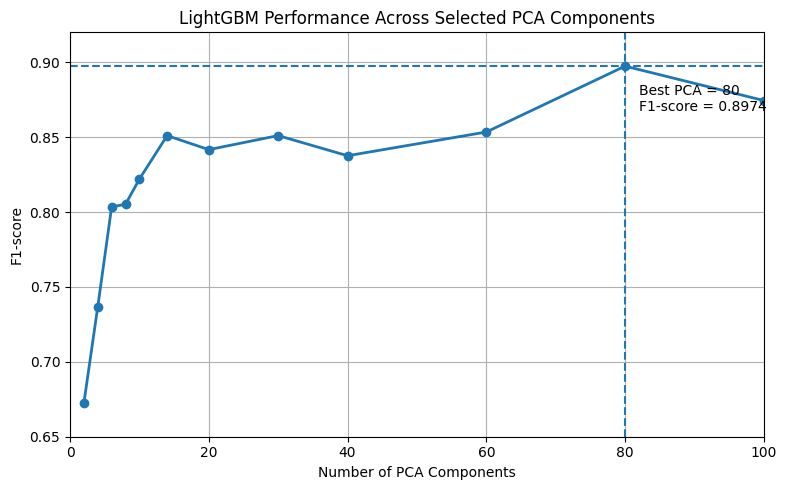

In [ ]:
IMG_SIZE = (200, 200)
TEST_SIZE = 0.15

component_list = [2, 4, 6, 8, 10, 14, 20, 30, 40, 60, 80, 100]

def smooth_image(img):
    return cv2.bilateralFilter(img, d=5, sigmaColor=50, sigmaSpace=50)

def load_pixels_smoothed_all(base_dir, classes, img_size):
    X, y = [], []

    for label, cls in enumerate(classes):
        cls_dir = os.path.join(base_dir, cls)

        if not os.path.isdir(cls_dir):
            continue

        for fn in os.listdir(cls_dir):
            path = os.path.join(cls_dir, fn)

            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, img_size)
            img = smooth_image(img)

            arr = img.astype(np.float32) / 255.0

            X.append(arr.flatten())
            y.append(label)

    return np.array(X), np.array(y)

print("Loading data...")
X, y = load_pixels_smoothed_all(DATA_DIR, classes, IMG_SIZE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=42
)

model = LGBMClassifier(
    n_estimators=600,
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

final_results = []
best = {
    "pca": None,
    "acc": 0,
    "precision": 0,
    "recall": 0,
    "f1": 0,
    "cm": None,
    "report": None
}

for n_comp in component_list:
    if n_comp >= X_train.shape[1]:
        continue

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_comp, random_state=42)),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        target_names=classes,
        zero_division=0
    )

    final_results.append((n_comp, acc, precision, recall, f1))

    if f1 > best["f1"]:
        best["pca"] = n_comp
        best["acc"] = acc
        best["precision"] = precision
        best["recall"] = recall
        best["f1"] = f1
        best["cm"] = cm
        best["report"] = report

final_results = sorted(final_results, key=lambda x: x[4], reverse=True)

print("\n=========== BEST LIGHTGBM RESULT ===========\n")
print(f"Best PCA   : {best['pca']}")
print(f"Accuracy   : {best['acc']:.4f}")
print(f"Precision  : {best['precision']:.4f}")
print(f"Recall     : {best['recall']:.4f}")
print(f"F1-score   : {best['f1']:.4f}")
print("Confusion Matrix:")
print(best["cm"])
print("Classification Report:")
print(best["report"])

plot_results = sorted(final_results, key=lambda x: x[0])
f1_map = {pca: f1 for pca, acc, precision, recall, f1 in plot_results}

selected_components = [2, 4, 6, 8, 10, 14, 20, 30, 40, 60, 80, 100]
selected_components = [x for x in selected_components if x in f1_map]
selected_f1 = [f1_map[x] for x in selected_components]

plt.figure(figsize=(8, 5))
plt.plot(
    selected_components,
    selected_f1,
    marker='o',
    linewidth=2
)
plt.axvline(x=best["pca"], linestyle='--')
plt.axhline(y=best["f1"], linestyle='--')
plt.text(
    best["pca"] + 2,
    best["f1"] - 0.03,
    f"Best PCA = {best['pca']}\nF1-score = {best['f1']:.4f}",
    fontsize=10
)

plt.xlabel("Number of PCA Components")
plt.ylabel("F1-score")
plt.title("LightGBM Performance Across Selected PCA Components")
plt.grid(True)
plt.xlim(0, 100)
plt.ylim(0.65, 0.92)
plt.tight_layout()
plt.show()

# 5) Before vs After Smoothing Comparison

In [ ]:
IMG_SIZE = (200, 200)
TEST_SIZE = 0.15

best_pca_map = {
    "LightGBM": 80,
    "RandomForest": 90,
    "ExtraTrees": 38,
    "GradientBoosting": 100,
    "XGBoost": 96,
    "KNN": 60,
    "SVM_RBF": 86,
    "LogisticRegression": 90,
    "DecisionTree": 33,
    "AdaBoost": 3
}

def smooth_image(img):
    return cv2.bilateralFilter(img, d=5, sigmaColor=50, sigmaSpace=50)


def load_data(use_smoothing=False):
    X, y = [], []

    for label, cls in enumerate(classes):
        cls_dir = os.path.join(DATA_DIR, cls)

        for fn in sorted(os.listdir(cls_dir)):
            path = os.path.join(cls_dir, fn)

            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, IMG_SIZE)

            if use_smoothing:
                img = smooth_image(img)

            arr = img.astype(np.float32) / 255.0

            X.append(arr.flatten())
            y.append(label)

    return np.array(X), np.array(y)


print("Loading WITHOUT smoothing...")
X_no, y_no = load_data(use_smoothing=False)

print("Loading WITH smoothing...")
X_sm, y_sm = load_data(use_smoothing=True)

X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(
    X_no, y_no,
    test_size=TEST_SIZE,
    stratify=y_no,
    random_state=42
)

X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
    X_sm, y_sm,
    test_size=TEST_SIZE,
    stratify=y_sm,
    random_state=42
)

models = {
    "LightGBM": LGBMClassifier(
        n_estimators=600,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    ) if HAS_LGBM else None,

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ) if HAS_XGB else None,

    "KNN": KNeighborsClassifier(
        n_neighbors=3,
        weights="distance"
    ),

    "SVM_RBF": SVC(
        C=2,
        gamma="scale",
        kernel="rbf",
        class_weight="balanced"
    ),

    "LogisticRegression": LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "DecisionTree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )
}

models = {k: v for k, v in models.items() if v is not None}

results = []

print("\n=========== BEFORE vs AFTER SMOOTHING (WITH BEST PCA) ===========\n")

for name, model in models.items():

    pca_val = best_pca_map[name]

    pipe_no = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=pca_val, random_state=42)),
        ("clf", model)
    ])

    pipe_no.fit(X_train_no, y_train_no)
    acc_no = accuracy_score(y_test_no, pipe_no.predict(X_test_no))

    pipe_sm = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=pca_val, random_state=42)),
        ("clf", model)
    ])

    pipe_sm.fit(X_train_sm, y_train_sm)
    acc_sm = accuracy_score(y_test_sm, pipe_sm.predict(X_test_sm))

    results.append({
        "Model": name,
        "PCA": pca_val,
        "Before_Smoothing": acc_no,
        "After_Smoothing": acc_sm,
        "Improvement": acc_sm - acc_no
    })

    print(
        f"{name:<18} | "
        f"PCA={pca_val:<3} | "
        f"Before={acc_no:.4f} | "
        f"After={acc_sm:.4f} | "
        f"Diff={acc_sm - acc_no:+.4f}"
    )

df = pd.DataFrame(results).sort_values(by="After_Smoothing", ascending=False)

print("\n=========== FINAL TABLE ===========\n")
print(df)

df.to_csv("best_pca_smoothing_comparison.csv", index=False)

print("\nSaved: best_pca_smoothing_comparison.csv")

Loading WITHOUT smoothing...
Loading WITH smoothing...

=========== BEFORE vs AFTER SMOOTHING (WITH BEST PCA) ===========

[LightGBM] [Info] Number of positive: 642, number of negative: 570
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20400
[LightGBM] [Info] Number of data points in the train set: 1212, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529703 -> initscore=0.118952
[LightGBM] [Info] Start training from score 0.118952
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa